<a href="https://colab.research.google.com/github/Shah4l/machine_learning_projects/blob/main/American_Housing_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
df=pd.read_csv("/content/American_Housing_Data_20231209.csv")

In [ ]:
df.head()

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,140 CHARLES ST APT 4D,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,38 JONES ST,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,81 BEDFORD ST APT 3F,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601


In [ ]:
df.tail()

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
39976,98199,2495000.0,4,4,3380,2626 27TH AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,3215 32ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,3257 22ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,3711 26TH PL W APT 102,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39980,98199,1150000.0,3,3,2840,2911 25TH AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [ ]:
df.shape

(39981, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39981 entries, 0 to 39980
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Zip Code                 39981 non-null  int64  
 1   Price                    39981 non-null  float64
 2   Beds                     39981 non-null  int64  
 3   Baths                    39981 non-null  int64  
 4   Living Space             39981 non-null  int64  
 5   Address                  39981 non-null  object 
 6   City                     39981 non-null  object 
 7   State                    39981 non-null  object 
 8   Zip Code Population      39981 non-null  int64  
 9   Zip Code Density         39981 non-null  float64
 10  County                   39981 non-null  object 
 11  Median Household Income  39979 non-null  float64
 12  Latitude                 39981 non-null  float64
 13  Longitude                39981 non-null  float64
dtypes: float64(5), int64(5

In [ ]:
df.isnull().sum()

,0
Zip Code,0
Price,0
Beds,0
Baths,0
Living Space,0
Address,0
City,0
State,0
Zip Code Population,0
Zip Code Density,0


In [ ]:
df.drop("Address",axis=1,inplace=True)

In [ ]:
df

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [ ]:
df['Median Household Income']=df['Median Household Income'].fillna(df['Median Household Income'].mean())

In [ ]:
df.isnull().sum()

,0
Zip Code,0
Price,0
Beds,0
Baths,0
Living Space,0
City,0
State,0
Zip Code Population,0
Zip Code Density,0
County,0


In [ ]:
df.dtypes

,0
Zip Code,int64
Price,float64
Beds,int64
Baths,int64
Living Space,int64
City,object
State,object
Zip Code Population,int64
Zip Code Density,float64
County,object


In [ ]:
le_city=LabelEncoder()
df['City']=le_city.fit_transform(df['City'])

le_state=LabelEncoder()
df['State']=le_state.fit_transform(df['State'])

le_country=LabelEncoder()
df['County']=le_country.fit_transform(df['County'])

In [ ]:
df

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223


In [ ]:
df.dtypes

,0
Zip Code,int64
Price,float64
Beds,int64
Baths,int64
Living Space,int64
City,int64
State,int64
Zip Code Population,int64
Zip Code Density,float64
County,int64


In [ ]:
x=df.drop('Price',axis=1)
y=df['Price']

In [ ]:
x

,Zip Code,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
1,10013,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
2,10014,1,1,718,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
3,10014,3,2,1538,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
4,10014,1,1,600,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,4,4,3380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39977,98199,4,4,2878,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39978,98199,3,2,1380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39979,98199,2,1,856,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223


In [ ]:
y

,Price
0,3999000.0
1,3999000.0
2,1650000.0
3,760000.0
4,1100000.0
...,...
39976,2495000.0
39977,2295000.0
39978,950000.0
39979,425000.0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(31984, 12)
(7997, 12)
(31984,)
(7997,)


In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.score(x_train,y_train)

0.43257443451347033

In [ ]:
model.score(x_test,y_test)

0.41426333452354136

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
pd.DataFrame({'True values':y_test,'Predicted':y_pred})

,True values,Predicted
7602,1590000.0,1.208037e+06
9287,249900.0,5.373727e+05
37271,1238000.0,1.488995e+06
33058,1095000.0,1.268316e+06
22916,179000.0,8.765424e+03
...,...,...
890,130000.0,1.643766e+05
4322,539900.0,2.075335e+05
17340,499900.0,1.343807e+06
20427,265000.0,-2.206837e+05


In [ ]:
mse=mean_squared_error(y_test,y_pred)
print(mse)

631921373147.367


In [ ]:
r2=r2_score(y_test,y_pred)
print(r2)

0.41426333452354136


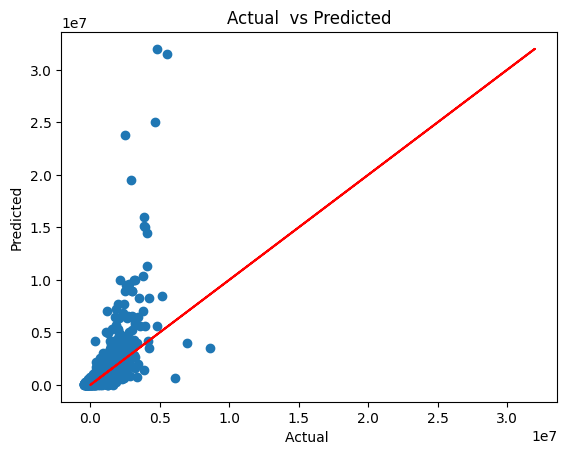

In [ ]:
plt.scatter(y_pred,y_test)
plt.plot(y_test,y_test,color="red")
plt.xlabel("Actual ")
plt.ylabel("Predicted")
plt.title("Actual  vs Predicted")
plt.show()